# 02 — Analisis *Mutual Information*

**Skripsi:** Implementasi *Time Series Foundation Model* Chronos-2 untuk Peramalan Probabilistik Harga Perak dengan Variabel Kovariat Harga Emas dan Dollar Index

Notebook ini menguji kelayakan **Emas (`GC=F`)** dan **Dollar Index (`DX-Y.NYB`)** sebagai kovariat bagi **Perak (`SI=F`)** menggunakan *Mutual Information* (MI).

**Ruang lingkup dan batasannya:**

- Seluruh komputasi diimpor dari `src/mutual_information.py`. Tidak ada estimator MI, uji permutasi, transformasi log-return, maupun logika pembagian data yang ditulis ulang di notebook ini. Fokus notebook adalah *penyajian*, bukan komputasi.
- Hanya `data/processed/train.csv` yang dimuat. Pemilihan kovariat adalah keputusan metodologis, sehingga tidak boleh menyandarkan diri pada data validasi maupun data uji — bila itu terjadi, evaluasi akhir menjadi optimistis secara semu (*data leakage*). Bagian 1 membuktikannya secara eksplisit lewat `assert`; data validasi dan data uji tidak pernah disentuh.
- Berkas gambar kanonis `mi_barplot.png` dan `mi_lag_plot.png` adalah keluaran `python -m src.mutual_information`. Notebook ini menampilkan versinya secara *inline* tanpa menimpa berkas tersebut, dan hanya menyimpan dua gambar baru yang memang tidak dihasilkan pipeline (bagian 5 dan 6).

**Mengapa dua varian?** MI pada level harga dan MI pada log-return menjawab pertanyaan yang berbeda. Notebook 01 sudah menunjukkan lewat ADF dan KPSS bahwa ketiga seri tidak stasioner pada level namun stasioner setelah di-*log-return*; bagian 6 di bawah memperlihatkan konsekuensinya secara visual.

In [1]:
import json
import sys
from pathlib import Path

# Tambahkan akar project ke sys.path agar `import src.*` bekerja dari folder notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import linregress

# Seluruh komputasi MI berasal dari src/
from src.mutual_information import (
    MODE_LABELS,
    MODE_LEVEL,
    MODE_LOG_RETURN,
    compute_mi_lagged,
    compute_mi_matrix,
    compute_mi_stable,
    load_train_data,
    permutation_null_distribution,
    transform_frame,
)
from src.mutual_information import _SERIES_COLORS  # palet yang sama dengan PNG pipeline
from src.preprocessing import get_covariate_columns, get_target_column
from src.utils import load_config, resolve_path

%matplotlib inline

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["savefig.bbox"] = "tight"
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

CONFIG = load_config()
MI_CONFIG = CONFIG["mutual_information"]
TARGET_COL = get_target_column(CONFIG)
COVARIATE_COLS = get_covariate_columns(CONFIG)
MODES = [MODE_LEVEL, MODE_LOG_RETURN]

FIGURES_DIR = resolve_path(CONFIG["paths"]["figures_dir"]) / "mutual_information"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TICKERS = {spec["column"]: spec["ticker"] for spec in CONFIG["data"]["tickers"].values()}

# Nama tampilan berbahasa Indonesia (khusus penyajian, bukan parameter pipeline)
DISPLAY_NAMES = {"silver": "Perak", "gold": "Emas", "dxy": "DXY"}
NAMES = {
    spec["column"]: DISPLAY_NAMES.get(key, key.upper())
    for key, spec in CONFIG["data"]["tickers"].items()
}
PAIR_LABELS = {c: f"{NAMES[TARGET_COL]}\u2013{NAMES[c]}" for c in COVARIATE_COLS}

# Warna diambil dari src agar gambar notebook identik dengan PNG keluaran pipeline
COVARIATE_COLORS = dict(zip(COVARIATE_COLS, _SERIES_COLORS))

print("Target      :", TARGET_COL, f"({TICKERS[TARGET_COL]})")
print("Kovariat    :", ", ".join(f"{c} ({TICKERS[c]})" for c in COVARIATE_COLS))
print("Parameter MI:", {k: MI_CONFIG[k] for k in
                        ("n_neighbors", "n_repeats", "n_permutations", "random_state")})

Target      : silver_close (SI=F)
Kovariat    : gold_close (GC=F), dxy_close (DX-Y.NYB)
Parameter MI: {'n_neighbors': 3, 'n_repeats': 20, 'n_permutations': 1000, 'random_state': 42}


## 1. Memuat data latih — dan membuktikan tidak ada kebocoran

`load_train_data()` hanya membaca `data/processed/train.csv`. Batas tanggal tiap split **dibaca** dari `results/metrics/data_quality_report.json` (keluaran `src/preprocessing.py`), bukan dihitung ulang di sini.

Blok `assert` di bawah adalah bukti formal yang dapat ditunjukkan ke penguji: bila satu saja observasi periode validasi atau uji ikut terbawa, sel ini gagal dan notebook berhenti.

In [2]:
train = load_train_data(config=CONFIG)

report_path = resolve_path(CONFIG["paths"]["metrics_dir"]) / "data_quality_report.json"
with report_path.open("r", encoding="utf-8") as file:
    SPLIT_INFO = json.load(file)["split"]["splits"]

train_start = pd.Timestamp(SPLIT_INFO["train"]["date_start"])
train_end = pd.Timestamp(SPLIT_INFO["train"]["date_end"])
val_start = pd.Timestamp(SPLIT_INFO["val"]["date_start"])
test_start = pd.Timestamp(SPLIT_INFO["test"]["date_start"])

# --- BUKTI TIDAK ADA KEBOCORAN DATA ---
assert train.index.max() == train_end, (
    f"Tanggal terakhir data latih {train.index.max().date()} "
    f"!= batas akhir split latih {train_end.date()}"
)
assert train.index.min() == train_start, "Tanggal awal data latih tidak sesuai laporan split"
assert len(train) == SPLIT_INFO["train"]["n_rows"], "Jumlah baris tidak sesuai laporan split"
assert train.index.max() < val_start, "Data latih menyentuh periode VALIDASI!"
assert train.index.max() < test_start, "Data latih menyentuh periode UJI!"
assert train.index.is_monotonic_increasing, "Indeks tanggal tidak terurut"
assert not train.index.has_duplicates, "Ada tanggal duplikat"

print("BUKTI TIDAK ADA KEBOCORAN DATA")
print("=" * 72)
print(f"  Berkas yang dimuat        : data/processed/train.csv  (HANYA berkas ini)")
print(f"  Jumlah baris              : {len(train)}"
      f"   (laporan preprocessing: {SPLIT_INFO['train']['n_rows']})")
print(f"  Tanggal awal data latih   : {train.index.min().date()}")
print(f"  Tanggal AKHIR data latih  : {train.index.max().date()}")
print(f"  Batas akhir split latih   : {train_end.date()}"
      f"   <-- SAMA PERSIS")
print("-" * 72)
print(f"  Awal periode validasi     : {val_start.date()}"
      f"   ({(val_start - train.index.max()).days} hari SETELAH akhir data latih)")
print(f"  Awal periode uji          : {test_start.date()}"
      f"   ({(test_start - train.index.max()).days} hari SETELAH akhir data latih)")
print("=" * 72)
print("Seluruh assert lolos: tidak satu pun observasi validasi/uji masuk ke analisis MI.")

train.head()

2026-09-21 22:50:55 | INFO     | mutual_information | Memuat data latih: 879 baris (2021-08-16 s.d. 2025-02-12) dari D:\project-skripsi\data\processed\train.csv
2026-09-21 22:50:55 | INFO     | mutual_information | Data validasi dan data uji TIDAK dibaca (mencegah kebocoran data).
BUKTI TIDAK ADA KEBOCORAN DATA
  Berkas yang dimuat        : data/processed/train.csv  (HANYA berkas ini)
  Jumlah baris              : 879   (laporan preprocessing: 879)
  Tanggal awal data latih   : 2021-08-16
  Tanggal AKHIR data latih  : 2025-02-12
  Batas akhir split latih   : 2025-02-12   <-- SAMA PERSIS
------------------------------------------------------------------------
  Awal periode validasi     : 2025-02-13   (1 hari SETELAH akhir data latih)
  Awal periode uji          : 2025-11-11   (272 hari SETELAH akhir data latih)
Seluruh assert lolos: tidak satu pun observasi validasi/uji masuk ke analisis MI.


,silver_close,gold_close,dxy_close,gold_ffilled,dxy_ffilled
date,,,,,
2021-08-16,23.7800,"1,786.9000",92.6300,False,False
2021-08-17,23.6480,"1,785.0000",93.1300,False,False
2021-08-18,23.4120,"1,781.6000",93.1400,False,False
2021-08-19,23.2200,"1,780.2000",93.5700,False,False
2021-08-20,23.1050,"1,781.0000",93.5000,False,False


## 2. Tabel perbandingan: MI vs Pearson vs Spearman

`compute_mi_matrix()` menghitung MI stabil (rata-rata dari `compute_mi_stable()`) sekaligus korelasi Pearson dan Spearman untuk tiap pasangan. Uji permutasi sengaja dilewati di sel ini (`run_permutation_test=False`) karena bagian 5 menghitungnya lengkap beserta distribusi nolnya.

Ketiga ukuran menjawab hal berbeda: **Pearson** hanya menangkap hubungan linear, **Spearman** menangkap hubungan monoton, sedangkan **MI** menangkap ketergantungan berbentuk apa pun. Selisih di antara ketiganya justru informasinya.

In [3]:
mi_results = {
    mode: compute_mi_matrix(train, mode, config=CONFIG, run_permutation_test=False)
    for mode in MODES
}

rows = []
for covariate in COVARIATE_COLS:
    level = mi_results[MODE_LEVEL]["pairs"][covariate]
    logret = mi_results[MODE_LOG_RETURN]["pairs"][covariate]
    rows.append(
        {
            "pasangan": PAIR_LABELS[covariate],
            "MI level (nat)": level["mi_mean"],
            "MI log-return (nat)": logret["mi_mean"],
            "rasio MI level / log-return": level["mi_mean"] / logret["mi_mean"],
            "Pearson r (level)": level["pearson"]["coefficient"],
            "Pearson r (log-return)": logret["pearson"]["coefficient"],
            "Spearman rho (level)": level["spearman"]["coefficient"],
            "Spearman rho (log-return)": logret["spearman"]["coefficient"],
        }
    )

comparison = pd.DataFrame(rows).set_index("pasangan")

print(f"n (level)      = {mi_results[MODE_LEVEL]['n_samples']}")
print(f"n (log-return) = {mi_results[MODE_LOG_RETURN]['n_samples']}"
      f"   (satu baris hilang akibat differencing)")
comparison.T

n (level)      = 879
n (log-return) = 878   (satu baris hilang akibat differencing)


pasangan,Perak–Emas,Perak–DXY
MI level (nat),1.3477,0.7753
MI log-return (nat),0.4150,0.0899
rasio MI level / log-return,3.2475,8.6226
Pearson r (level),0.9324,-0.0187
Pearson r (log-return),0.7785,-0.4063
Spearman rho (level),0.8464,-0.1533
Spearman rho (log-return),0.7546,-0.3959


### Catatan pembacaan tabel

Perhatikan baris **Pearson r (level)** untuk Perak–DXY. Nilainya nyaris nol padahal MI-nya besar. Inilah alasan penelitian ini memakai MI, bukan korelasi, sebagai dasar pemilihan kovariat: keterkaitan Perak dengan Dollar Index memang ada, tetapi bentuknya tidak linear sehingga tak terbaca oleh koefisien korelasi.

## 3. Barplot MI dengan *error bar* dari `compute_mi_stable()`

Estimator MI berbasis k-NN bersifat stokastik: ia menambahkan derau kecil untuk memecah nilai kembar, sehingga satu kali pemanggilan bisa memberi hasil sedikit berbeda. `compute_mi_stable()` mengulang perhitungan sebanyak `n_repeats` kali dengan `random_state` berurutan, lalu melaporkan rata-rata dan simpangan bakunya. Simpangan baku itulah yang digambar sebagai *error bar* — semakin pendek, semakin stabil estimasinya.

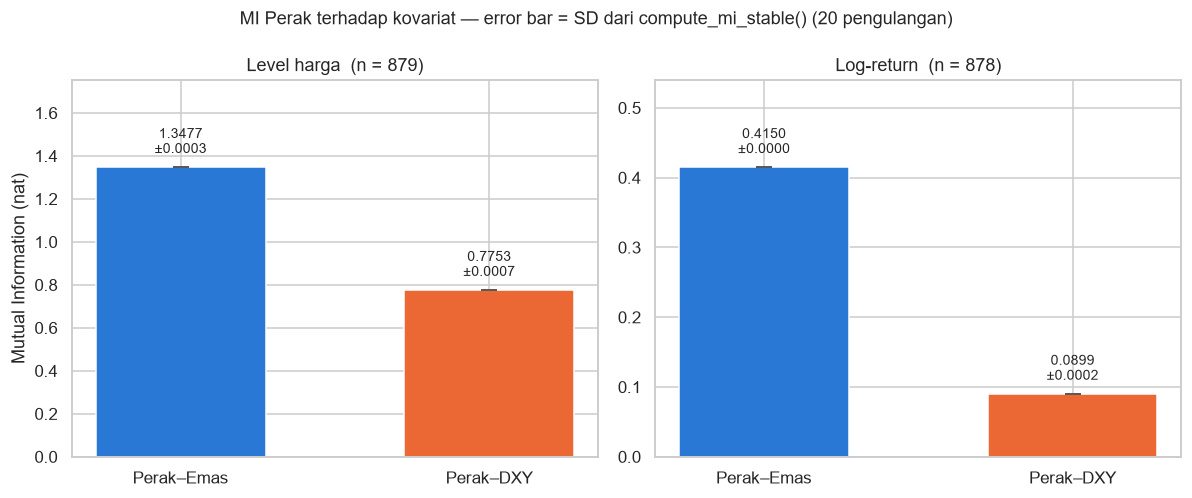

MI (mean)  SD antar-pengulangan  \
varian      pasangan                                      
Level harga Perak–Emas     1.3477                0.0003   
            Perak–DXY      0.7753                0.0007   
Log-return  Perak–Emas     0.4150                0.0000   
            Perak–DXY      0.0899                0.0002   

                        SD sebagai % dari mean  
varian      pasangan                            
Level harga Perak–Emas                  0.0210  
            Perak–DXY                   0.0869  
Log-return  Perak–Emas                  0.0000  
            Perak–DXY                   0.2634

In [4]:
# compute_mi_stable() dipanggil eksplisit agar terlihat dari mana error bar berasal
stable = {}
for mode in MODES:
    transformed = transform_frame(train, mode, [TARGET_COL, *COVARIATE_COLS]).dropna()
    for covariate in COVARIATE_COLS:
        stable[(mode, covariate)] = compute_mi_stable(
            transformed[covariate].to_numpy(),
            transformed[TARGET_COL].to_numpy(),
            n_repeats=MI_CONFIG["n_repeats"],
            n_neighbors=MI_CONFIG["n_neighbors"],
            random_state=MI_CONFIG["random_state"],
        )

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

for ax, mode in zip(axes, MODES):
    means = [stable[(mode, c)][0] for c in COVARIATE_COLS]
    stds = [stable[(mode, c)][1] for c in COVARIATE_COLS]
    positions = np.arange(len(COVARIATE_COLS))

    ax.bar(
        positions,
        means,
        width=0.55,
        color=[COVARIATE_COLORS[c] for c in COVARIATE_COLS],
        yerr=stds,
        capsize=5,
        error_kw={"ecolor": "#52514e", "elinewidth": 1.3},
        zorder=2,
    )
    for position, mean, std in zip(positions, means, stds):
        ax.text(
            position,
            mean + std + max(means) * 0.035,
            f"{mean:.4f}\n\u00b1{std:.4f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.set_xticks(positions)
    ax.set_xticklabels([PAIR_LABELS[c] for c in COVARIATE_COLS])
    ax.set_ylim(0, max(means) * 1.30)
    ax.set_title(f"{MODE_LABELS[mode]}  (n = {mi_results[mode]['n_samples']})")

axes[0].set_ylabel("Mutual Information (nat)")
fig.suptitle(
    f"MI Perak terhadap kovariat \u2014 error bar = SD dari compute_mi_stable() "
    f"({MI_CONFIG['n_repeats']} pengulangan)",
    fontsize=12,
)
fig.tight_layout()
plt.show()

pd.DataFrame(
    [
        {
            "varian": MODE_LABELS[mode],
            "pasangan": PAIR_LABELS[c],
            "MI (mean)": stable[(mode, c)][0],
            "SD antar-pengulangan": stable[(mode, c)][1],
            "SD sebagai % dari mean": stable[(mode, c)][1] / stable[(mode, c)][0] * 100,
        }
        for mode in MODES
        for c in COVARIATE_COLS
    ]
).set_index(["varian", "pasangan"])

## 4. MI terhadap lag 0–5

Yang dihitung adalah MI antara **Perak$_t$** dan **kovariat$_{t-lag}$**. Pertanyaannya: apakah nilai kovariat *kemarin* masih membawa informasi tentang Perak *hari ini*? Kalau ya, kovariat punya efek *lead*; kalau tidak, keterkaitannya murni sezaman.

Pertanyaan ini penting karena Chronos-2 hanya diberi kovariat masa lalu (*past-only*) — nilai Emas dan DXY di masa depan tidak diketahui saat peramalan dilakukan.

Config menyimpan `lags: [0, 1, 2, 3, 5]`; notebook menyapu rentang **kontinu 0–5** (batas atasnya tetap diambil dari config) supaya bentuk kurvanya utuh.

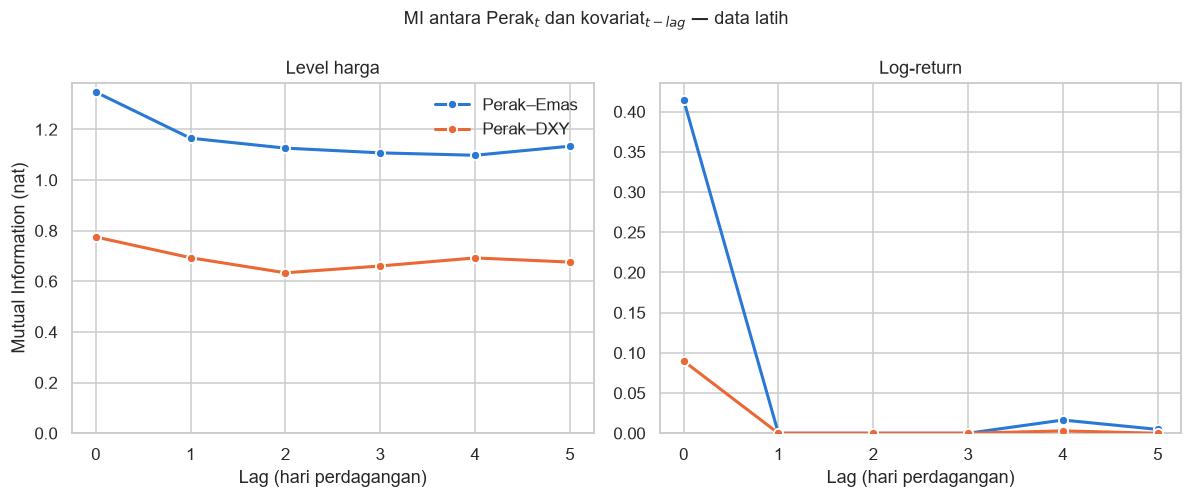

lag 0  lag 1  lag 2  lag 3  lag 4  lag 5
varian      pasangan                                            
Level harga Perak–Emas 1.3477 1.1654 1.1262 1.1075 1.0980 1.1337
            Perak–DXY  0.7753 0.6932 0.6338 0.6606 0.6925 0.6761
Log-return  Perak–Emas 0.4150 0.0000 0.0000 0.0000 0.0164 0.0048
            Perak–DXY  0.0899 0.0000 0.0000 0.0000 0.0030 0.0000

In [5]:
LAGS = list(range(0, max(MI_CONFIG["lags"]) + 1))  # 0..5 kontinu

lag_results = {
    mode: compute_mi_lagged(train, LAGS, mode, config=CONFIG) for mode in MODES
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

for ax, mode in zip(axes, MODES):
    for covariate in COVARIATE_COLS:
        series = lag_results[mode]["pairs"][covariate]
        means = np.array([point["mi_mean"] for point in series])
        stds = np.array([point["mi_std"] for point in series])

        ax.fill_between(
            LAGS, means - stds, means + stds,
            color=COVARIATE_COLORS[covariate], alpha=0.15, linewidth=0,
        )
        ax.plot(
            LAGS, means,
            color=COVARIATE_COLORS[covariate],
            linewidth=2.0, marker="o", markersize=6,
            markeredgecolor="white", markeredgewidth=1.2,
            label=PAIR_LABELS[covariate], zorder=3,
        )

    ax.set_xticks(LAGS)
    ax.set_xlabel("Lag (hari perdagangan)")
    ax.set_ylim(bottom=0)
    ax.set_title(MODE_LABELS[mode])

axes[0].set_ylabel("Mutual Information (nat)")
axes[0].legend(frameon=False)
fig.suptitle(
    "MI antara Perak$_t$ dan kovariat$_{t-lag}$ \u2014 data latih", fontsize=12
)
fig.tight_layout()
plt.show()

lag_table = pd.DataFrame(
    {
        (MODE_LABELS[mode], PAIR_LABELS[c]): [
            point["mi_mean"] for point in lag_results[mode]["pairs"][c]
        ]
        for mode in MODES
        for c in COVARIATE_COLS
    },
    index=[f"lag {lag}" for lag in LAGS],
).T
lag_table.index.names = ["varian", "pasangan"]
lag_table

## 5. Distribusi nol uji permutasi

Hipotesis nol: Perak dan kovariat saling bebas. Distribusi nol dibentuk dengan mengacak urutan seri Perak sebanyak `n_permutations` kali dan menghitung MI setiap kali — nilai MI yang muncul murni karena kebetulan. Nilai p adalah proporsi `MI_null >= MI_teramati`, dengan koreksi tambah-satu $(1+k)/(1+n)$ agar tidak pernah tepat nol.

Garis vertikal berwarna menandai MI yang benar-benar teramati. Semakin jauh garis itu dari gumpalan histogram, semakin kecil kemungkinan keterkaitannya muncul karena kebetulan.

Pada panel yang pemisahannya sangat lebar, distribusi nol tergencet menjadi garis tipis di tepi kiri. Karena itu ditambahkan **kotak zoom** (*inset*) yang memperlihatkan bentuk distribusi nolnya sendiri; sumbu utama tetap memakai skala penuh supaya besarnya jarak ke MI teramati tidak menyesatkan.

Angka *MI teramati* di sini berasal dari **satu** kali pemanggilan dengan `random_state` tetap (bukan rata-rata 20 pengulangan seperti bagian 2 dan 3), sehingga dapat berbeda pada desimal keempat — selisihnya masih di dalam simpangan baku yang dilaporkan bagian 3.

> **Peringatan metodologis.** Permutasi mengasumsikan pengamatan saling bebas. Pada varian **level**, harga sangat berautokorelasi sehingga asumsi itu dilanggar dan nilai p-nya bersifat *anti-konservatif* (terlalu optimistis) — dipakai sebagai indikasi, bukan bukti formal. Pada varian **log-return** asumsi tersebut jauh lebih masuk akal, dan itulah baris yang dipakai untuk menyimpulkan kelayakan kovariat.

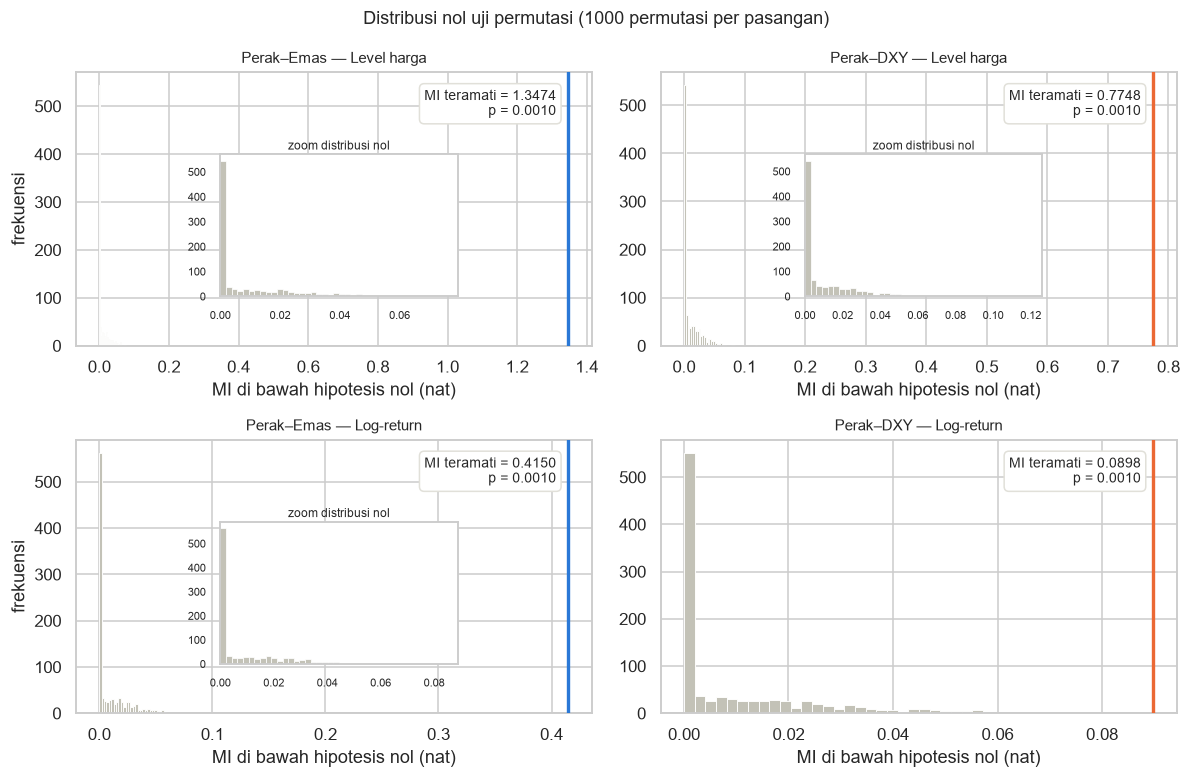

Tersimpan: D:\project-skripsi\results\figures\mutual_information\mi_null_distribution.png


MI teramati  null mean  null q95  null max  \
varian      pasangan                                                 
Level harga Perak–Emas       1.3474     0.0101    0.0435    0.0757   
            Perak–DXY        0.7748     0.0102    0.0438    0.1202   
Log-return  Perak–Emas       0.4150     0.0097    0.0423    0.0846   
            Perak–DXY        0.0898     0.0095    0.0430    0.0818   

                        jumlah null >= teramati  p-value  
varian      pasangan                                      
Level harga Perak–Emas                        0   0.0010  
            Perak–DXY                         0   0.0010  
Log-return  Perak–Emas                        0   0.0010  
            Perak–DXY                         0   0.0010

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.2))
perm_rows = []

for row, mode in enumerate(MODES):
    transformed = transform_frame(train, mode, [TARGET_COL, *COVARIATE_COLS]).dropna()

    for col, covariate in enumerate(COVARIATE_COLS):
        ax = axes[row, col]

        mi_observed, null_values = permutation_null_distribution(
            transformed[covariate].to_numpy(),
            transformed[TARGET_COL].to_numpy(),
            n_permutations=MI_CONFIG["n_permutations"],
            random_state=MI_CONFIG["random_state"],
            n_neighbors=MI_CONFIG["n_neighbors"],
        )

        n_ge = int(np.count_nonzero(null_values >= mi_observed))
        p_value = (1 + n_ge) / (1 + len(null_values))
        perm_rows.append(
            {
                "varian": MODE_LABELS[mode],
                "pasangan": PAIR_LABELS[covariate],
                "MI teramati": mi_observed,
                "null mean": null_values.mean(),
                "null q95": np.quantile(null_values, 0.95),
                "null max": null_values.max(),
                "jumlah null >= teramati": n_ge,
                "p-value": p_value,
            }
        )

        ax.hist(null_values, bins=40, color="#c3c2b7", edgecolor="white", linewidth=0.6)
        ax.axvline(
            mi_observed, color=COVARIATE_COLORS[covariate], linewidth=2.2, zorder=3
        )
        ax.annotate(
            f"MI teramati = {mi_observed:.4f}\np = {p_value:.4f}",
            xy=(mi_observed, ax.get_ylim()[1] * 0.94),
            xytext=(-8, 0),
            textcoords="offset points",
            ha="right",
            va="top",
            fontsize=9,
            bbox={"boxstyle": "round,pad=0.35", "facecolor": "white",
                  "edgecolor": "#e1e0d9"},
        )
        ax.set_title(f"{PAIR_LABELS[covariate]} \u2014 {MODE_LABELS[mode]}", fontsize=10)
        ax.set_xlabel("MI di bawah hipotesis nol (nat)")
        if col == 0:
            ax.set_ylabel("frekuensi")

        # Bila MI teramati jauh di luar distribusi nol, histogramnya tergencet
        # menjadi garis tipis. Kotak zoom memperlihatkan bentuk aslinya.
        if mi_observed > 2 * null_values.max():
            inset = ax.inset_axes([0.28, 0.18, 0.46, 0.52])
            inset.hist(
                null_values, bins=40, color="#c3c2b7",
                edgecolor="white", linewidth=0.5,
            )
            inset.set_xlim(0, null_values.max() * 1.05)
            inset.set_title("zoom distribusi nol", fontsize=8, pad=3)
            inset.tick_params(labelsize=7)
            inset.grid(False)
            inset.set_facecolor("white")

fig.suptitle(
    f"Distribusi nol uji permutasi ({MI_CONFIG['n_permutations']} permutasi per pasangan)",
    fontsize=12,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "mi_null_distribution.png")
plt.show()

print("Tersimpan:", FIGURES_DIR / "mi_null_distribution.png")
pd.DataFrame(perm_rows).set_index(["varian", "pasangan"])

## 6. Mengapa MI level jauh lebih besar? — bukti visual

Ini bagian yang paling menjelaskan. Empat panel berikut memakai data yang sama, hanya berbeda transformasi. **Warna titik menyatakan urutan waktu** (terang = awal periode latih, gelap = akhir), sehingga struktur temporalnya terlihat langsung.

- **Baris atas (level harga):** titik-titiknya tidak menyebar acak melainkan membentuk *lintasan* yang merambat rapi dari terang ke gelap. Yang "dikenali" MI di sini sebagian besar adalah **tren bersama** — ketiga aset sama-sama naik sepanjang 2021–2025 — bukan keterkaitan pergerakan harian. Karena posisi sebuah titik sangat ditentukan oleh *kapan* ia terjadi, MI-nya membengkak.
- **Baris bawah (log-return):** setelah differencing, tren hilang dan yang tersisa adalah awan titik tanpa arah waktu. Warna gelap dan terang tercampur merata. MI yang terukur di sini adalah keterkaitan **hari-ke-hari** yang sesungguhnya — jauh lebih kecil, tetapi inilah yang benar-benar dapat dieksploitasi untuk peramalan.

Notebook 01 sudah menunjukkan hal yang sama secara formal: ADF dan KPSS sepakat bahwa ketiga seri tidak stasioner pada level dan stasioner setelah di-*log-return*.

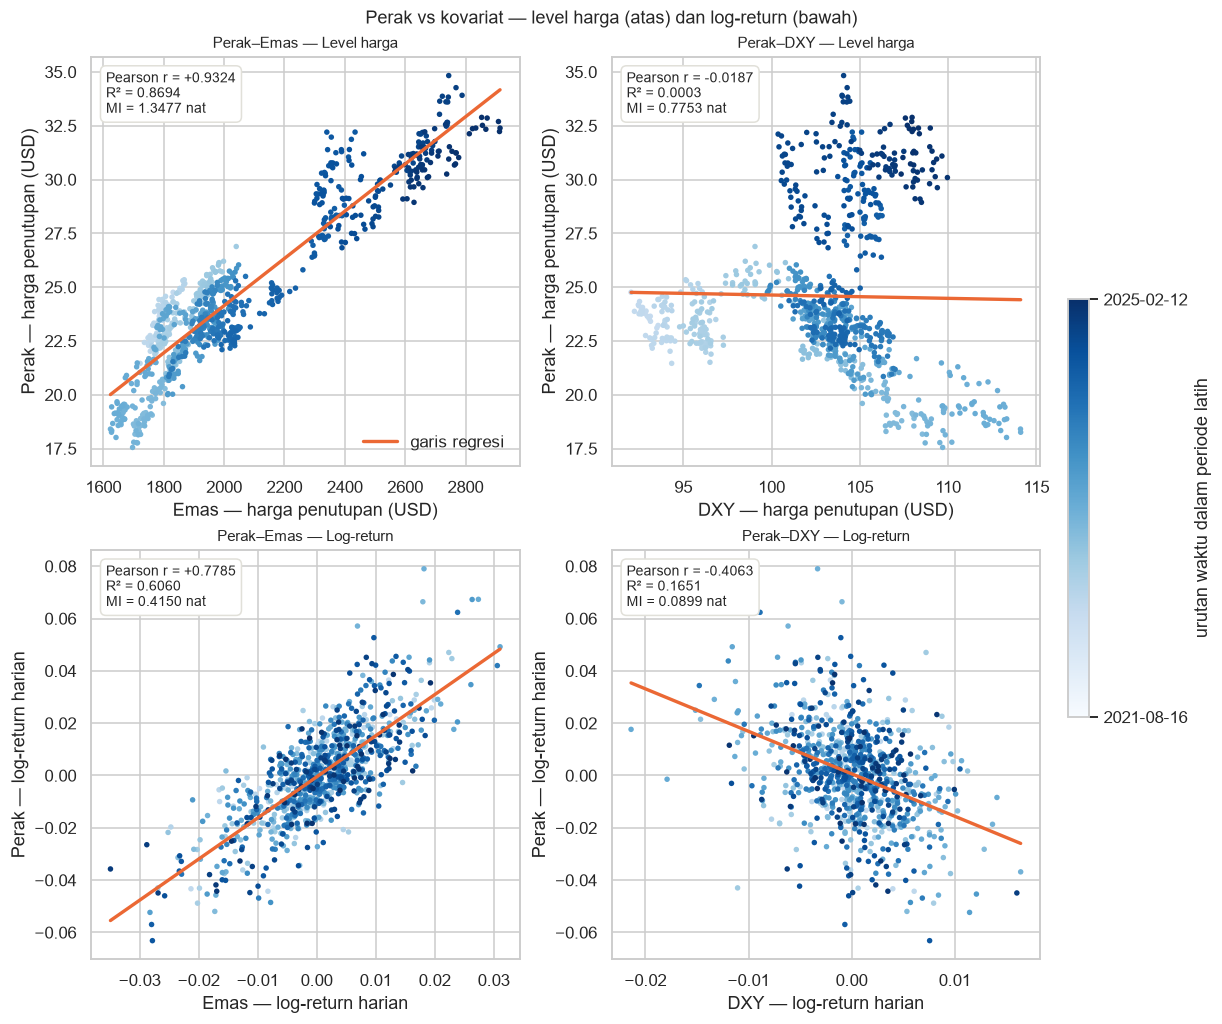

Tersimpan: D:\project-skripsi\results\figures\mutual_information\mi_scatter_level_vs_logreturn.png


slope  Pearson r     R2  MI (nat)
varian      pasangan                                      
Level harga Perak–Emas  0.0110     0.9324 0.8694    1.3477
            Perak–DXY  -0.0154    -0.0187 0.0003    0.7753
Log-return  Perak–Emas  1.5714     0.7785 0.6060    0.4150
            Perak–DXY  -1.6237    -0.4063 0.1651    0.0899

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9.2), layout="constrained")
scatter_rows = []

for row, mode in enumerate(MODES):
    transformed = transform_frame(train, mode, [TARGET_COL, *COVARIATE_COLS]).dropna()
    # Gradasi satu warna (Blues) menyatakan urutan waktu; mulai 0.25 agar tidak pudar
    time_shade = np.linspace(0.25, 1.0, len(transformed))
    unit = "harga penutupan (USD)" if mode == MODE_LEVEL else "log-return harian"

    for col, covariate in enumerate(COVARIATE_COLS):
        ax = axes[row, col]
        x = transformed[covariate].to_numpy()
        y = transformed[TARGET_COL].to_numpy()

        ax.scatter(x, y, c=plt.cm.Blues(time_shade), s=13, linewidths=0, zorder=2)

        fit = linregress(x, y)
        grid = np.linspace(x.min(), x.max(), 100)
        ax.plot(
            grid, fit.intercept + fit.slope * grid,
            color="#eb6834", linewidth=2.2, zorder=3, label="garis regresi",
        )

        mi_value = mi_results[mode]["pairs"][covariate]["mi_mean"]
        ax.annotate(
            f"Pearson r = {fit.rvalue:+.4f}\n"
            f"R\u00b2 = {fit.rvalue ** 2:.4f}\n"
            f"MI = {mi_value:.4f} nat",
            xy=(0.035, 0.965),
            xycoords="axes fraction",
            va="top",
            fontsize=9,
            bbox={"boxstyle": "round,pad=0.4", "facecolor": "white",
                  "edgecolor": "#e1e0d9"},
        )

        ax.set_xlabel(f"{NAMES[covariate]} \u2014 {unit}")
        ax.set_ylabel(f"{NAMES[TARGET_COL]} \u2014 {unit}")
        ax.set_title(f"{PAIR_LABELS[covariate]} \u2014 {MODE_LABELS[mode]}", fontsize=10)

        scatter_rows.append(
            {
                "varian": MODE_LABELS[mode],
                "pasangan": PAIR_LABELS[covariate],
                "slope": fit.slope,
                "Pearson r": fit.rvalue,
                "R2": fit.rvalue ** 2,
                "MI (nat)": mi_value,
            }
        )

axes[0, 0].legend(frameon=False, loc="lower right")

# Colorbar bersama: menerjemahkan gradasi warna menjadi tanggal
mappable = plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=plt.Normalize(0.25, 1.0))
colorbar = fig.colorbar(
    mappable, ax=axes.ravel().tolist(), fraction=0.022, pad=0.02
)
colorbar.set_ticks([0.25, 1.0])
colorbar.set_ticklabels([str(train.index.min().date()), str(train.index.max().date())])
colorbar.set_label("urutan waktu dalam periode latih")

fig.suptitle(
    "Perak vs kovariat \u2014 level harga (atas) dan log-return (bawah)", fontsize=12
)
fig.savefig(FIGURES_DIR / "mi_scatter_level_vs_logreturn.png")
plt.show()

print("Tersimpan:", FIGURES_DIR / "mi_scatter_level_vs_logreturn.png")
pd.DataFrame(scatter_rows).set_index(["varian", "pasangan"])

## 7. Kesimpulan — justifikasi kelayakan kovariat (siap salin ke laporan)

Analisis *Mutual Information* dilakukan **hanya pada data latih** (879 hari perdagangan, 16 Agustus 2021 sampai 12 Februari 2025), sehingga pemilihan kovariat tidak mengambil informasi apa pun dari data validasi maupun data uji. MI diestimasi dengan *estimator* k-terdekat (`mutual_info_regression`, k = 3) dan dilaporkan sebagai rata-rata dari 20 pengulangan dengan *random state* berbeda, karena estimator tersebut bersifat stokastik. Simpangan baku antar-pengulangan terbukti sangat kecil (di bawah 0,1% dari nilai rata-rata pada seluruh pasangan), sehingga estimasi MI dapat dianggap stabil.

Pada **level harga**, MI Perak terhadap Emas sebesar **1,3477 nat** dan terhadap Dollar Index sebesar **0,7753 nat**. Setelah kedua seri ditransformasi menjadi **log-return**, nilainya turun menjadi **0,4150 nat** dan **0,0899 nat**, yaitu 3,2 dan 8,6 kali lebih kecil. Penyusutan ini bukan pertanda kovariatnya lemah, melainkan konsekuensi langsung dari sifat non-stasioner ketiga seri: pada level harga, Perak, Emas, dan Dollar Index sama-sama merupakan proses ber-tren, sehingga *estimator* k-NN sebagian besar sedang mengukur kesamaan lintasan tren jangka panjang, bukan keterkaitan pergerakan harian. Uji ADF dan KPSS pada Notebook 01 menegaskan hal ini — ketiga seri tidak stasioner pada level dan stasioner setelah di-*log-return* — dan diagram pencar pada bagian 6 memperlihatkannya secara visual: pada level, titik-titik membentuk lintasan berurutan menurut waktu, sedangkan pada log-return titik-titik menyebar sebagai awan tanpa arah waktu. Karena itu **MI pada log-return-lah yang dipakai sebagai dasar penilaian kelayakan**, sedangkan MI pada level dilaporkan untuk keperluan pembanding sesuai narasi proposal.

Kedua kovariat dinyatakan **layak dipakai**. Uji permutasi dengan 1.000 permutasi menolak hipotesis kemandirian untuk keempat pasangan pada varian log-return maupun level (seluruhnya *p* = 0,001, nilai terkecil yang dapat dicapai dengan 1.000 permutasi). Untuk pasangan yang keterkaitannya paling lemah sekalipun, yaitu Perak–DXY pada log-return, MI teramati 0,0899 nat masih berada di atas nilai maksimum seluruh distribusi nol (0,0818 nat) dan jauh di atas kuantil 95%-nya (0,0430 nat). Hasil ini diperkuat oleh temuan bahwa pada level harga korelasi Pearson Perak–DXY hanya **−0,0187** — praktis nol — padahal MI-nya 0,7753 nat. Artinya keterkaitan Perak dengan Dollar Index nyata tetapi **tidak linear**, sehingga tidak akan terdeteksi bila pemilihan kovariat hanya bersandar pada koefisien korelasi. Inilah justifikasi metodologis penggunaan *Mutual Information* dalam penelitian ini.

Analisis MI berlag memberi batasan penting terhadap ekspektasi. Pada varian log-return, MI runtuh dari 0,4150 nat (lag 0) menjadi 0,0000 nat pada lag 1 sampai 3 untuk Perak–Emas, dan dari 0,0899 nat menjadi 0,0000 nat untuk Perak–DXY; nilai kecil yang muncul kembali pada lag 4 (0,0164 dan 0,0030 nat) berada dalam rentang derau *estimator*. Dengan kata lain **kedua kovariat bergerak sezaman dengan Perak, bukan mendahuluinya** — temuan yang konsisten dengan hipotesis pasar efisien. Sebaliknya pada level harga MI tetap tinggi di seluruh lag (Perak–Emas 1,0980–1,3477 nat), yang sekali lagi menunjukkan bahwa yang bertahan di sana adalah tren bersama, bukan informasi prediktif. Konsekuensinya bagi rancangan model: manfaat Emas dan Dollar Index sebagai *past-only covariates* terletak pada pengayaan konteks yang dibaca Chronos-2 — memperjelas rezim volatilitas dan arah pasar yang sedang berlangsung — bukan pada kemampuan meramal beberapa hari ke depan dari kovariat itu sendiri.

---

### Tabel rujukan angka

| Ukuran | Perak–Emas | Perak–DXY |
|---|---|---|
| MI level (nat) | 1,3477 | 0,7753 |
| MI log-return (nat) | 0,4150 | 0,0899 |
| Rasio MI level / log-return | 3,25 | 8,62 |
| SD MI level (20 pengulangan) | 0,0003 | 0,0007 |
| SD MI log-return (20 pengulangan) | 0,0000 | 0,0002 |
| Pearson *r* (level) | +0,9324 | −0,0187 |
| Pearson *r* (log-return) | +0,7785 | −0,4063 |
| Spearman *rho* (level) | +0,8464 | −0,1533 |
| Spearman *rho* (log-return) | +0,7546 | −0,3959 |
| *p* uji permutasi (level) | 0,001 | 0,001 |
| *p* uji permutasi (log-return) | 0,001 | 0,001 |
| MI log-return pada lag 1 (nat) | 0,0000 | 0,0000 |
| MI level pada lag 1 (nat) | 1,1654 | 0,6932 |

**Parameter analisis:** `n_neighbors` = 3, `n_repeats` = 20, `n_permutations` = 1.000, `random_state` = 42, lag yang diuji 0–5 hari perdagangan. Jumlah observasi: 879 (level) dan 878 (log-return, satu baris hilang akibat differencing).

**Catatan metodologis.** Nilai *p* uji permutasi pada varian **level** bersifat anti-konservatif karena permutasi mengandaikan pengamatan saling bebas, sedangkan harga sangat berautokorelasi; nilai tersebut dilaporkan sebagai indikasi dan kesimpulan kelayakan kovariat disandarkan pada varian log-return. MI dilaporkan dalam satuan *nat* (logaritma natural) dan tidak memiliki batas atas, sehingga besarannya hanya bermakna bila dibandingkan antar-pasangan pada varian yang sama — bukan dibandingkan lintas varian.

---

*Seluruh angka pada bagian ini dihasilkan oleh `src/mutual_information.py` dan tersimpan lengkap di `results/metrics/mutual_information.json`. Notebook ini hanya memanggil dan menyajikannya.*